In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\shobh\OneDrive\Attachments\Documents\Desktop\py\Mall_Customers.csv")

df = pd.DataFrame(data)

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


# project description

Customer Segmentation & Marketing Strategy using Machine Learning is an unsupervised machine learning project that uses the K-Means Clustering algorithm to group customers based on purchasing behavior. The project enables businesses to identify distinct customer segments, personalize marketing campaigns, optimize customer engagement, and improve strategic decision-making through data-driven insights.

In [3]:
#dataset understanding 

# outliers detection 

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)


outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]

outliers

-1.625 79.375


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


<h2 style="color:#059669;">➤ Observation :</h2></b> <b>➜ This Dataset have no outliers

In [4]:
#data cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.nunique()

CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

In [10]:
df.value_counts()

CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
1           Male    19   15                  39                        1
2           Male    21   15                  81                        1
3           Female  20   16                  6                         1
4           Female  23   16                  77                        1
5           Female  31   17                  40                        1
                                                                      ..
196         Female  35   120                 79                        1
197         Female  45   126                 28                        1
198         Male    32   126                 74                        1
199         Male    32   137                 18                        1
200         Male    30   137                 83                        1
Name: count, Length: 200, dtype: int64

In [11]:
df.sample(30)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
179,180,Male,35,93,90
61,62,Male,19,46,55
64,65,Male,63,48,51
142,143,Female,28,76,40
94,95,Female,32,60,42
88,89,Female,34,58,60
153,154,Female,38,78,76
116,117,Female,63,65,43
187,188,Male,28,101,68
0,1,Male,19,15,39


<h2 style="color:#B91C1C; font-family:Georgia;">
Graphs for Data Visualization :
</h2>

In [12]:
df.sample()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
174,175,Female,52,88,13


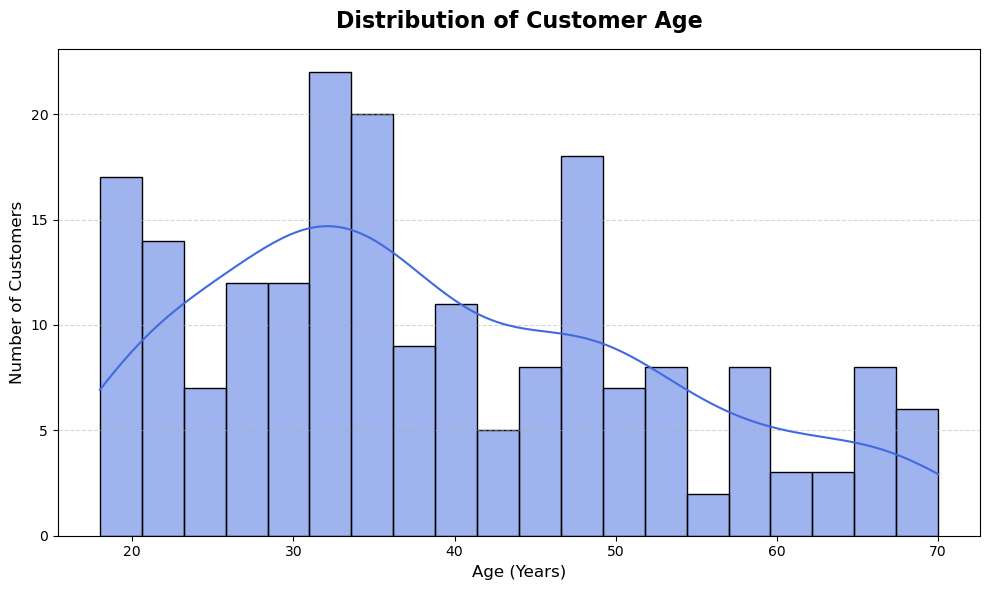

In [13]:
#Age distribution

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='Age',  bins=20, color='royalblue', edgecolor='black' ,kde=True)

plt.title("Distribution of Customer Age", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()


plt.savefig(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\Graphs\Age Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

In [14]:
df.sample()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
94,95,Female,32,60,42


C:\Users\shobh\AppData\Local\Temp\ipykernel_17680\912213874.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Gender',palette='Set2',edgecolor='black')


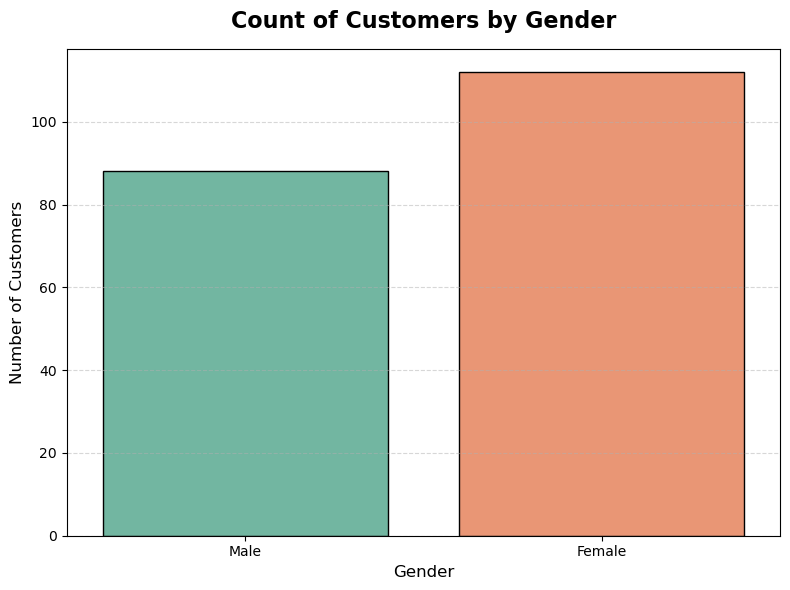

In [15]:
# Count of Customers by Gender

plt.figure(figsize=(8, 6))

sns.countplot(data=df,x='Gender',palette='Set2',edgecolor='black')

plt.title("Count of Customers by Gender", fontsize=16, fontweight='bold', pad=15)

plt.xlabel("Gender", fontsize=12)

plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()


plt.savefig(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\Graphs\Gender Count.png",
    dpi=300,bbox_inches="tight")

plt.show()

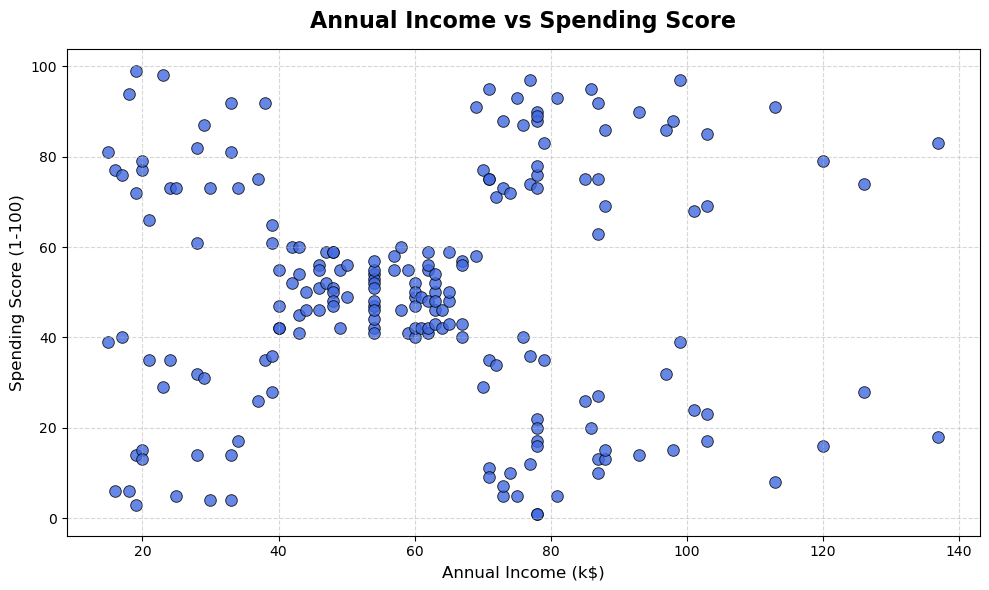

In [16]:
#Income vs Spendings Relationship Graph


plt.figure(figsize=(10, 6))

sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',color='royalblue',s=70,edgecolor='black',alpha=0.8)

plt.title("Annual Income vs Spending Score", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\Graphs\Income vs Spending Score.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

<h2 style="color:#059669;">➤ <b>Overall EDA Observations</b></h2>

<b>➜ The dataset is clean and contains no missing values duplicate records or significant outliers</b><br><br>

<b>➜ Most customers belong to the 30 to 40 years age group indicating that the mall primarily attracts young and middle aged customers</b><br><br>

<b>➜ Customers with similar annual incomes exhibit different spending behaviors showing that income alone does not determine spending patterns</b><br><br>

<b>➜ The relationship between Annual Income and Spending Score reveals multiple natural customer groups suitable for segmentation</b><br><br>

<b>➜ No strong linear relationship exists between Annual Income and Spending Score making clustering a more suitable approach than regression</b><br><br>

<b>➜ The dataset demonstrates clear customer segmentation potential making K Means an appropriate algorithm for identifying meaningful customer groups</b><br><br>

<b>➜ These insights can help businesses understand customer behavior improve targeted marketing strategies and enhance customer engagement</b>

<b>➜ The absence of a strong linear relationship between Annual Income and Spending Score indicates that clustering techniques are more appropriate than regression for identifying customer segments

In [17]:
# now feature enginnering 


# K-Means is an unsupervised learning algorithm
# Since there is no target variable, train-test split is not required


#encoding 

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df.to_csv(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\data\encoded_customer_data.csv",
    index=False)

In [18]:
df.head(12)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
5,6,0,22,17,76
6,7,0,35,18,6
7,8,0,23,18,94
8,9,1,64,19,3
9,10,0,30,19,72


In [19]:
# now scaling right ?

X = df.drop(columns=["CustomerID", "Gender"])
X

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [20]:
#scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
#saving scaler model
import pickle

pickle.dump(scaler,open(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\models\scaler.pkl",
                        "wb"))

In [22]:
# now lets apply elbow methord to find optimal number of K clusters

In [23]:
#elbow methord

#finiding Within-Cluster Sum of Squares

from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i,random_state=42,n_init="auto")
    model.fit(X_scaled)
    wcss.append(model.inertia_)


wcss


C:\Users\shobh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shobh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shobh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shobh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[600.0,
 389.3861889564372,
 295.4562449213556,
 205.22514747675913,
 169.89149793438582,
 134.35277477401496,
 121.3893502250287,
 113.72723000071335,
 102.13623844329251,
 92.55027231838785]

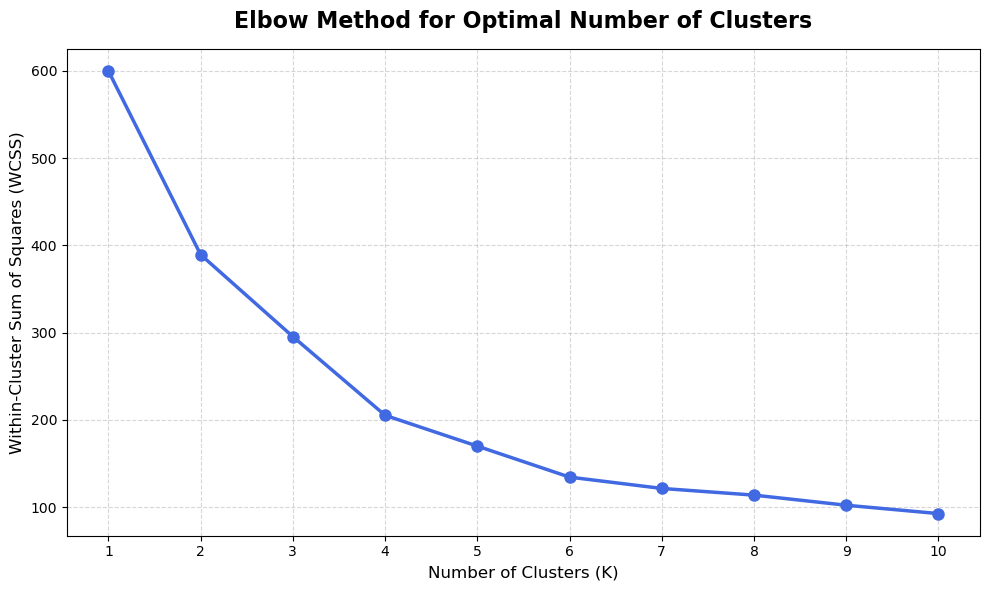

In [24]:
# plotting elbow graph to find best K


plt.figure(figsize=(10, 6))

plt.plot(range(1, 11),wcss,marker='o',markersize=8,linewidth=2.5,color='royalblue')

plt.title("Elbow Method for Optimal Number of Clusters", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=12)

plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\Graphs\Elbow Method.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

<h2 style="color:#059669;">➤ <b>Overall Observations</b></h2>

<b>➜ According To Elbow Methord K = 4 will beoptimal number of clusters</b><br><br>

In [25]:
#now lets train our model 

kmeans = KMeans(n_clusters = 4 , random_state = 42 , n_init= 10 )

clusters = kmeans.fit_predict(X_scaled)

clusters

C:\Users\shobh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2,
       2, 0, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 3, 2, 2, 2, 0, 0, 0, 0, 2, 3, 1, 1, 3, 1, 3, 1, 0, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [26]:
#saving this kmeans model too 

import pickle

pickle.dump(kmeans,open(
        r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\models\kmeans_model.pkl","wb"))

In [27]:
# adding clusters to original df to provide every customer a segment label

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,2
1,2,1,21,15,81,2
2,3,0,20,16,6,2
3,4,0,23,16,77,2
4,5,0,31,17,40,2


In [31]:
# Final Insights 

df_cluster = df.drop(columns = ['CustomerID','Gender'])

df_cluster.groupby("Cluster").mean(numeric_only=True)

df_cluster.to_csv(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\data\cluster_insights.csv",
    index=True
)

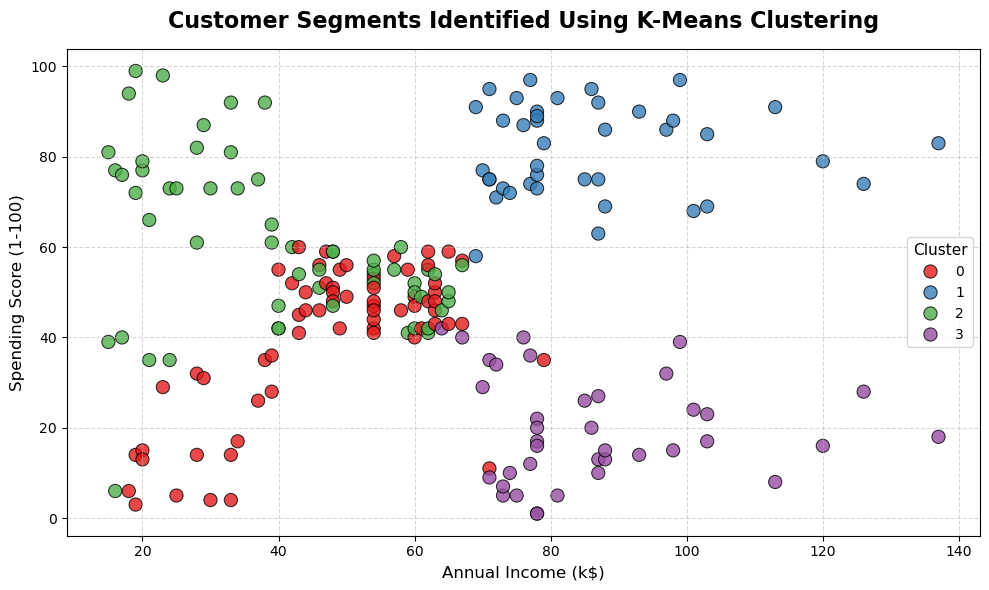

In [35]:
# Customer Segments



plt.figure(figsize=(10, 6))

sns.scatterplot(data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=90,edgecolor="black",alpha=0.8)

plt.title("Customer Segments Identified Using K-Means Clustering", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Annual Income (k$)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)

plt.legend(title="Cluster", fontsize=10, title_fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Retail Customer Segmentation using  Clustering\Graphs\Customer Segments.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

In [32]:
df_cluster

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,2
3,23,16,77,2
4,31,17,40,2
...,...,...,...,...
195,35,120,79,1
196,45,126,28,3
197,32,126,74,1
198,32,137,18,3


In [34]:
df_cluster.groupby("Cluster").mean(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,53.984615,47.707692,39.969231
1,32.875000,86.100000,81.525000
2,25.438596,40.000000,60.298246
3,39.368421,86.500000,19.578947


In [ ]:
df["Cluster"].value_counts()

<h2 style="color:#059669;">➤ <b>Overall Cluster Analysis and Business Insights</b></h2>

<b>➜ The K Means Clustering model successfully identified four distinct customer segments based on Age Annual Income and Spending Score</b><br><br>

<b>➜ Cluster 1 : represents the most valuable customer segment with high annual income high spending behavior and a relatively young average age making these customers ideal for VIP memberships exclusive rewards premium services and early access offers</b><br><br>

<b>➜ Cluster 3 contains customers with high annual income but very low spending behavior indicating strong purchasing power that remains underutilized making this segment suitable for personalized promotions luxury product recommendations and targeted marketing campaigns</b><br><br>

<b>➜ Cluster 2 consists of the youngest customers with moderate income and above average spending behavior showing strong shopping interest making this segment highly responsive to student offers seasonal discounts loyalty rewards and social media marketing campaigns</b><br><br>

<b>➜ Cluster 0 contains the largest number of customers with the highest average age moderate income and relatively low spending behavior suggesting that value based offers senior citizen benefits and personalized engagement strategies may improve customer retention and spending</b><br><br>

<b>➜ Customers with similar annual incomes demonstrate significantly different spending behaviors proving that annual income alone cannot accurately represent customer purchasing patterns</b><br><br>

<b>➜ The distribution of customers across all four clusters indicates that the mall serves multiple customer groups with different shopping preferences requiring separate marketing strategies instead of a single common approach</b><br><br>

<b>➜ The successful identification of meaningful customer segments demonstrates that K Means Clustering is an effective approach for customer segmentation and strategic business decision making</b>

<h2 style="color:#059669; border-bottom:3px solid #10B981; padding-bottom:8px; font-family:Segoe UI;">
 End of Notebook
</h2>